In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import learning_curve

In [2]:
df = pd.read_csv("RealEstate_HousePrice_Dataset.csv")

In [3]:
df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


# TARGET VARIABLE


In [5]:
target = "house_price_inr"



PART D : SIMPLE LINEAR REGRESSION
Coefficient : 14788.306111307536
Intercept : -1163519.1764186025
MAE : 6294593.696131912
RMSE : 8184696.696997969
R2 : 0.5625199587991578


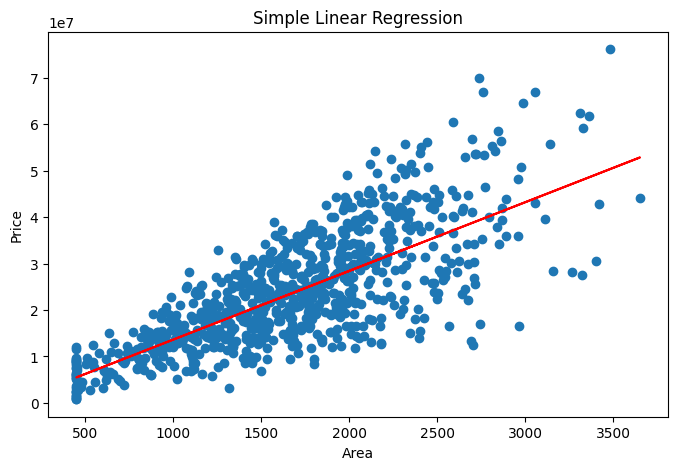

In [6]:
df_clean = df.copy()


print("\n")
print("="*60)
print("PART D : SIMPLE LINEAR REGRESSION")
print("="*60)

X = df_clean[['area_sqft']]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

slr = LinearRegression()

slr.fit(X_train,y_train)

pred = slr.predict(X_test)

print("Coefficient :", slr.coef_[0])
print("Intercept :", slr.intercept_)

print("MAE :", mean_absolute_error(y_test,pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test,pred)))
print("R2 :", r2_score(y_test,pred))

plt.figure(figsize=(8,5))
plt.scatter(X_test,y_test)
plt.plot(X_test,pred,color='red')
plt.title("Simple Linear Regression")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()